First we read the train and test folders and check the distributions



Notes:

->This code uses the train and test folder inside the dataset directory.

->These folders are taken from the Wifi_and_MQTT folder in the downloaded
CIC-IoMT-DIAD-2024 dataset.


In [1]:
## Imports

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:


# Change this to your dataset root
DATASET_ROOT = "..\Dataset"

def get_class_distribution(split_dir):
    """
    Count samples per CSV file inside split_dir (train or test).
    Returns a DataFrame with class name and number of samples.
    """
    rows = []
    for fname in os.listdir(split_dir):
        if fname.endswith(".csv"):
            class_name = os.path.splitext(fname)[0]  # filename without .csv
            fpath = os.path.join(split_dir, fname)
            try:
                # Load just enough rows to count quickly
                df = pd.read_csv(fpath)
                n_samples = len(df)
            except Exception as e:
                print(f"Error reading {fpath}: {e}")
                n_samples = 0
            rows.append({"class": class_name, "samples": n_samples})
    return pd.DataFrame(rows).sort_values("samples", ascending=False)

# Train split
train_dir = os.path.join(DATASET_ROOT, "train")
train_dist = get_class_distribution(train_dir)
print("Train distribution:")
print(train_dist)

# Test split
test_dir = os.path.join(DATASET_ROOT, "test")
test_dist = get_class_distribution(test_dir)
print("\nTest distribution:")
print(test_dist)

# Merge for global view
train_dist["split"] = "train"
test_dist["split"] = "test"
all_dist = pd.concat([train_dist, test_dist], ignore_index=True)

# Pivot for summary
summary = all_dist.pivot_table(values="samples", index="class", columns="split", fill_value=0)
summary["total"] = summary.sum(axis=1)

print("\nOverall distribution (train/test/total):")
print(summary)

# Save to CSV for later inspection
#summary.to_csv("class_distribution_summary.csv")

Then we categorize them into 6 different categories as mentioned by the dataset authors
1) Benign
2) DDoS
3) DoS
4) MQTT
5) Recon
6) Spoofing

In [ ]:



def map_group(class_name):
    c = class_name.lower()
    if "arp_spoofing" in c:
        return "Spoofing"
    elif "recon" in c:
        return "Recon"
    elif "mqtt" in c:
        return "MQTT"
    elif "ddos" in c:
        return "DDoS"
    elif "dos" in c:
        return "DoS"
    elif "benign" in c:
        return "Benign"
    else:
        return "Other"

# Apply mapping
train_dist["group"] = train_dist["class"].apply(map_group)
test_dist["group"] = test_dist["class"].apply(map_group)

# Summarize
train_grouped = train_dist.groupby("group")["samples"].sum().reset_index().sort_values("samples", ascending=False)
test_grouped = test_dist.groupby("group")["samples"].sum().reset_index().sort_values("samples", ascending=False)

# Merge
all_grouped = pd.merge(train_grouped, test_grouped, on="group", how="outer", suffixes=("_train", "_test")).fillna(0)
all_grouped["total"] = all_grouped["samples_train"] + all_grouped["samples_test"]

#print("Grouped distribution (train/test/total):")
#print(all_grouped)

# Save for later
#all_grouped.to_csv("grouped_class_distribution.csv", index=False)


Distribute them into Train, Test and Val Split as 80/10/10


Notes:

->This code creates a new folder named as final_split

-> final_split folder will contain 3 csv files named as train,test and val


In [ ]:



# Paths
DATASET_ROOT = "..\Dataset"
train_dir = os.path.join(DATASET_ROOT, "train")
test_dir = os.path.join(DATASET_ROOT, "test")

# Define grouping rules
def map_group(class_name):
    c = class_name.lower()
    if "arp_spoofing" in c:
        return "Spoofing"
    elif "recon" in c:
        return "Recon"
    elif "mqtt" in c:
        return "MQTT"
    elif "ddos" in c:
        return "DDoS"
    elif "dos" in c:
        return "DoS"
    elif "benign" in c:
        return "Benign"
    else:
        return "Other"

def load_and_group(input_dir):
    all_dfs = []
    for fname in os.listdir(input_dir):
        if fname.endswith(".csv"):
            class_name = os.path.splitext(fname)[0]
            group = map_group(class_name)

            fpath = os.path.join(input_dir, fname)
            try:
                df = pd.read_csv(fpath)
            except Exception as e:
                print(f"Error reading {fpath}: {e}")
                continue

            # Add label column
            df["label"] = group
            all_dfs.append(df)

    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()

# Load train and test folders
train_df = load_and_group(train_dir)
test_df = load_and_group(test_dir)

# Combine everything
full_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Full dataset shape: {full_df.shape}")
print(full_df["label"].value_counts())

# Split into 80/10/10 (stratified by label)
train_df, temp_df = train_test_split(
    full_df, test_size=0.2, stratify=full_df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Save splits
output_dir = os.path.join(DATASET_ROOT, "final_split")
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(os.path.join(output_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test.csv"), index=False)

print(f"Saved train/val/test CSVs to {output_dir}")



Full dataset shape: (9162994, 40)
label
DDoS        5846623
DoS         2222205
MQTT         883951
Recon        131402
Benign        56898
Spoofing      21915
Name: count, dtype: int64
Train size: 7330395
Val size: 916299
Test size: 916300
Saved train/val/test CSVs to ..\Dataset\final_split


Analyze and Validate the data distribution across the splits


Notes:

->This code creates csv file inside the Preprocessing folder that will contain the class distributions.

In [ ]:


# Path where you saved the final splits
DATASET_ROOT = r"..\Dataset\final_split"

# Function to check distribution
def check_distribution(file_path, split_name):
    df = pd.read_csv(file_path)
    counts = df["label"].value_counts().reset_index()
    counts.columns = ["class", "samples"]
    counts["split"] = split_name
    return counts

# Load distributions
train_dist = check_distribution(os.path.join(DATASET_ROOT, "train.csv"), "train")
val_dist   = check_distribution(os.path.join(DATASET_ROOT, "val.csv"), "val")
test_dist  = check_distribution(os.path.join(DATASET_ROOT, "test.csv"), "test")

# Combine
all_dist = pd.concat([train_dist, val_dist, test_dist], ignore_index=True)

# Pivot for summary
summary = all_dist.pivot_table(values="samples", index="class", columns="split", fill_value=0)
summary["total"] = summary.sum(axis=1)

print("Class distribution across splits:")
print(summary)

# Save for later inspection
summary.to_csv(os.path.join(".\\", "class_distribution_summary.csv"))


Class distribution across splits:
split         test      train       val      total
class                                             
Benign      5690.0    45518.0    5690.0    56898.0
DDoS      584663.0  4677298.0  584662.0  5846623.0
DoS       222221.0  1777764.0  222220.0  2222205.0
MQTT       88395.0   707161.0   88395.0   883951.0
Recon      13140.0   105122.0   13140.0   131402.0
Spoofing    2191.0    17532.0    2192.0    21915.0


Preprocessing

1) Checking for Unique Values

In [ ]:


DATASET_ROOT = r"D:\IoMT\Dataset\final_split" 
train_file = os.path.join(DATASET_ROOT, "train.csv")
CARDINALITY_THRESHOLD = 50

print(f"Loading data from: {train_file}")
print("This may take a moment...")
try:
    # We only need the training set for this analysis
    df = pd.read_csv(train_file)
    print(f"Successfully loaded {len(df)} rows and {len(df.columns)} columns.")
except FileNotFoundError:
    print(f"ERROR: File not found at {train_file}")
    print("Please check your DATASET_ROOT path.")
    exit()
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    exit()

print("\n--- Analyzing Columns ---")


for col in df.columns:
    print(f"\n### Column: '{col}'")
    
    # Checking for infinities first
    if pd.api.types.is_numeric_dtype(df[col]):
        inf_count = np.isinf(df[col]).sum()
        if inf_count > 0:
            print(f"  [!] Note: Contains {inf_count} infinite values (inf or -inf)")
            
    # Check for NaNs
    nan_count = df[col].isnull().sum()
    if nan_count > 0:
        print(f"  [!] Note: Contains {nan_count} NaN (missing) values")

    # Get the number of unique values
    num_unique = df[col].nunique()
    
    if num_unique <= CARDINALITY_THRESHOLD:
       
        print(f"  Type:           Categorical (Low-Cardinality)")
        print(f"  Unique Count:   {num_unique}")
        
       
        unique_vals = df[col].unique()
        print(f"  Unique Values:  {unique_vals}")
    
    else:
        
        print(f"  Type:           Continuous (High-Cardinality)")
        print(f"  Unique Count:   {num_unique}")
        
        
        if pd.api.types.is_numeric_dtype(df[col]):
            
            col_data = df[col].replace([np.inf, -np.inf], np.nan)
            print(f"  Min:            {col_data.min():.4f}")
            print(f"  Max:            {col_data.max():.4f}")
            print(f"  Mean:           {col_data.mean():.4f}")
            print(f"  Std. Dev:       {col_data.std():.4f}")
        else:
            
            print("  Note:           Non-numeric, high-cardinality data.")
            
            print(f"  Samples:        {df[col].sample(3).values}")

print("\n--- Analysis Complete ---")


Loading data from: D:\IoMT\Dataset\after_imputation\train.csv
This may take a moment...
Successfully loaded 7330395 rows and 40 columns.

--- Analyzing Columns ---

### Column: 'Header_Length'
  Type:           Continuous (High-Cardinality)
  Unique Count:   1699
  Min:            0.0000
  Max:            48.0000
  Mean:           12.5799
  Std. Dev:       10.3375

### Column: 'Protocol Type'
  Type:           Categorical (Low-Cardinality)
  Unique Count:   5
  Unique Values:  [17  6  1  0  2]

### Column: 'Time_To_Live'
  Type:           Continuous (High-Cardinality)
  Unique Count:   7832
  Min:            0.0000
  Max:            255.0000
  Mean:           64.4655
  Std. Dev:       6.0884

### Column: 'Rate'
  Type:           Continuous (High-Cardinality)
  Unique Count:   160243
  Min:            0.0015
  Max:            104857600.0000
  Mean:           1049757.1727
  Std. Dev:       10084096.6048

### Column: 'fin_flag_number'
  Type:           Continuous (High-Cardinality)
  Uniq

Now we will impute the inf with max value 
and imput the NaN with 0.0

This code will save the updated files in the "after_imputation" directory

In [4]:

DATASET_ROOT = r"D:\IoMT\Dataset\final_split"
train_file = os.path.join(DATASET_ROOT, "train.csv")
val_file   = os.path.join(DATASET_ROOT, "val.csv")
test_file  = os.path.join(DATASET_ROOT, "test.csv")
OUTPUT_DIR = r"D:\IoMT\Dataset\after_imputation"

output_train_file = os.path.join(OUTPUT_DIR, "train.csv")
output_val_file   = os.path.join(OUTPUT_DIR, "val.csv")
output_test_file  = os.path.join(OUTPUT_DIR, "test.csv")
train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(val_file)
test_df  = pd.read_csv(test_file)

print(f"Original shapes (Train/Val/Test):")
print(f"{train_df.shape} / {val_df.shape} / {test_df.shape}")


print("\nHandling 'inf' values in 'Rate' column...")
for df in [train_df, val_df, test_df]:
    
    df.loc[:, 'Rate'] = df['Rate'].replace([np.inf, -np.inf], np.nan)


max_rate = train_df['Rate'].max()
print(f"Calculated Max Finite Rate (from train set): {max_rate}")


print(f"Imputing 'inf' (now NaN) in 'Rate' with {max_rate}...")
for df in [train_df, val_df, test_df]:
    df['Rate'].fillna(max_rate, inplace=True)



print("\nHandling 'NaN' values in 'Std' and 'Variance'...")
for df in [train_df, val_df, test_df]:
    df['Std'].fillna(0.0, inplace=True)
    df['Variance'].fillna(0.0, inplace=True)


print("Filling any remaining NaNs with 0...")
for df in [train_df, val_df, test_df]:
    df.fillna(0.0, inplace=True)


print("\n--- Preprocessing Complete ---")
print("Total NaNs remaining in training data:")
print(train_df.isna().sum().sum())

print("\nFinal shapes (Train/Val/Test):")
print(f"{train_df.shape} / {val_df.shape} / {test_df.shape}")


print(f"Saving preprocessed training data to {output_train_file}...")
train_df.to_csv(output_train_file, index=False)

print(f"Saving preprocessed validation data to {output_val_file}...")
val_df.to_csv(output_val_file, index=False)

print(f"Saving preprocessed test data to {output_test_file}...")
test_df.to_csv(output_test_file, index=False)

print("\nAll preprocessed files saved successfully.")

Original shapes (Train/Val/Test):
(7330395, 40) / (916299, 40) / (916300, 40)

Handling 'inf' values in 'Rate' column...
Calculated Max Finite Rate (from train set): 104857600.0
Imputing 'inf' (now NaN) in 'Rate' with 104857600.0...

Handling 'NaN' values in 'Std' and 'Variance'...


C:\Users\azwad.aziz\AppData\Local\Temp\ipykernel_5112\754637353.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rate'].fillna(max_rate, inplace=True)
C:\Users\azwad.aziz\AppData\Local\Temp\ipykernel_5112\754637353.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

Filling any remaining NaNs with 0...

--- Preprocessing Complete ---
Total NaNs remaining in training data:
0

Final shapes (Train/Val/Test):
(7330395, 40) / (916299, 40) / (916300, 40)
Saving preprocessed training data to D:\IoMT\Dataset\after_imputation\train.csv...
Saving preprocessed validation data to D:\IoMT\Dataset\after_imputation\val.csv...
Saving preprocessed test data to D:\IoMT\Dataset\after_imputation\test.csv...

All preprocessed files saved successfully.


Now we will obsserve the correlation heatmap 
to identify the redundancies

Loading preprocessed training data...
Data loaded successfully.
Found 31 continuous features for correlation analysis.
Calculating correlation matrix...
Generating heatmap... This may take a moment.

--- Heatmap saved to D:\IoMT\Dataset\after_redundancy_removal\correlation_heatmap.png ---

Recommendation: Open the .png file to analyze.
Look for bright red (1.0) or dark blue (-1.0) squares to find redundancies.


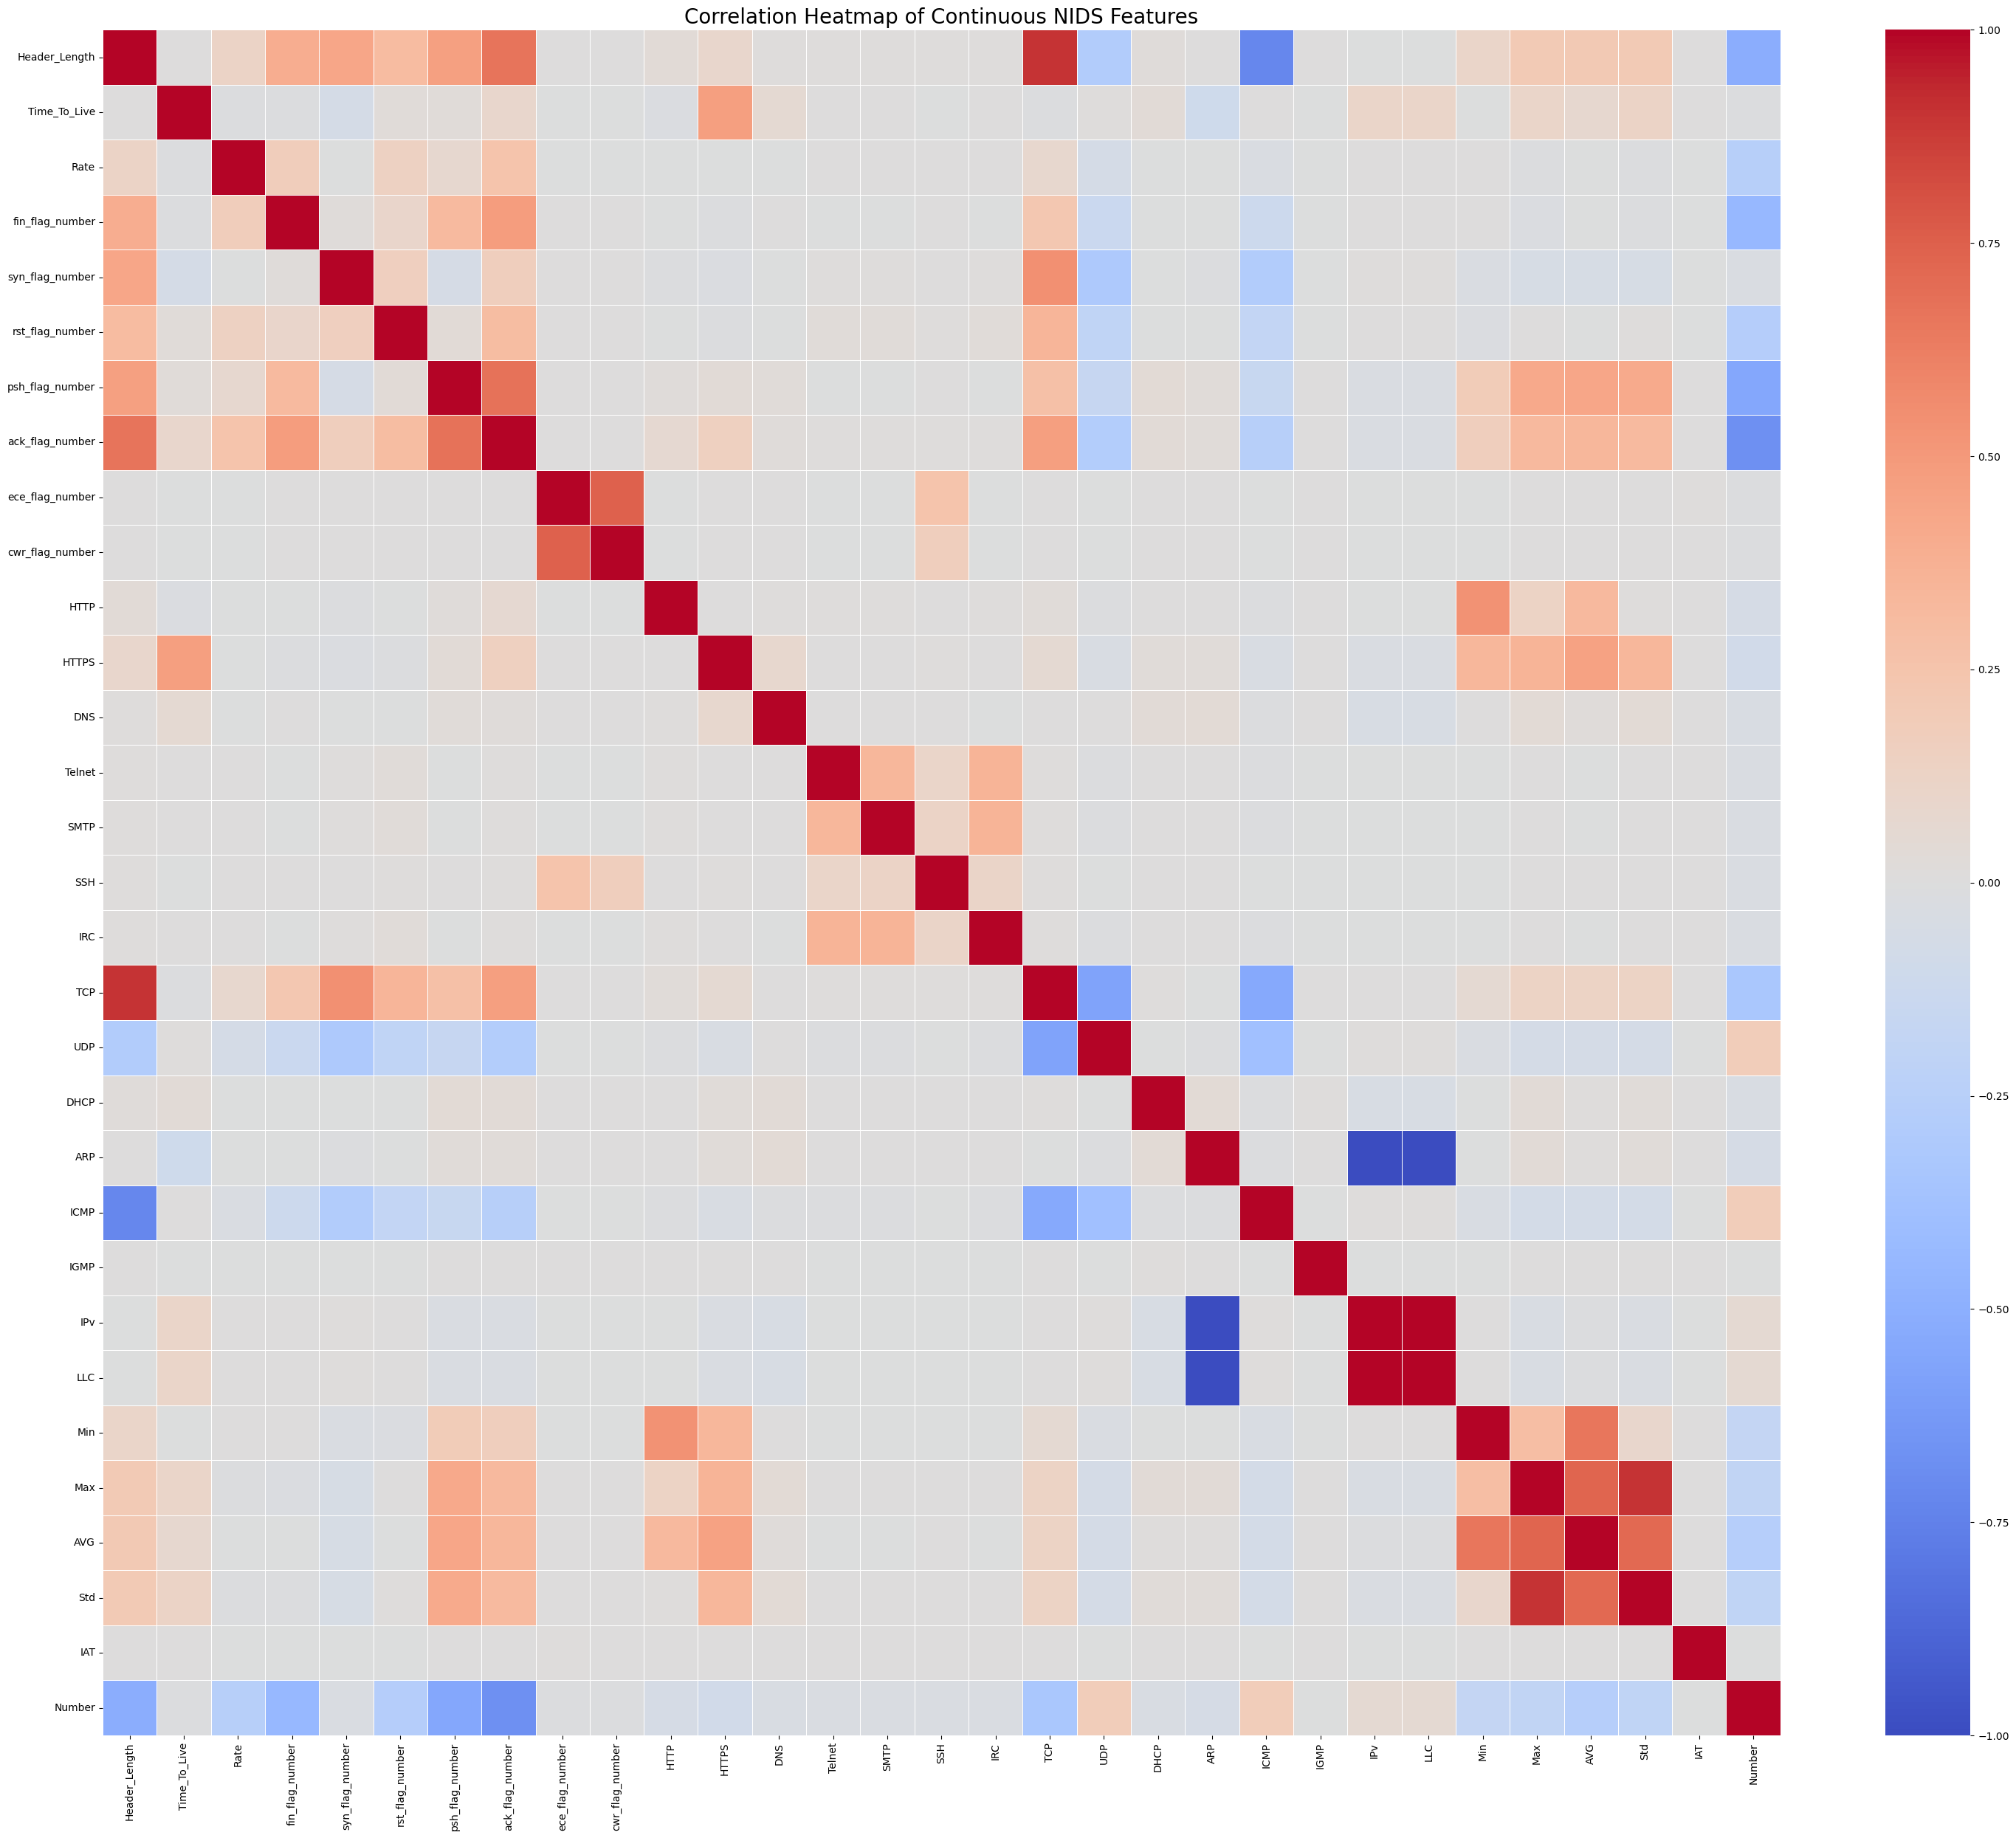

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


INPUT_DIR = r"D:\IoMT\Dataset\after_imputation"  
train_file = os.path.join(INPUT_DIR, "train.csv")

print("Loading preprocessed training data...")
try:
    df = pd.read_csv(train_file)
except FileNotFoundError:
    print(f"ERROR: File not found at {train_file}")
    print("Please make sure you have run the imputation/saving script first.")
    exit()

print("Data loaded successfully.")




all_cols = df.columns.tolist()


categorical_cols = ['Protocol Type', 'label']


continuous_cols = [col for col in all_cols if col not in categorical_cols]

print(f"Found {len(continuous_cols)} continuous features for correlation analysis.")


print("Calculating correlation matrix...")

corr_matrix = df[continuous_cols].corr()


print("Generating heatmap... This may take a moment.")
plt.figure(figsize=(30, 25))  
sns.heatmap(corr_matrix, 
            annot=False,       
            cmap='coolwarm',   
            linewidths=0.5,
            fmt=".1f")
plt.title('Correlation Heatmap of Continuous NIDS Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()


output_image_path = os.path.join(INPUT_DIR, "correlation_heatmap.png")
plt.savefig(output_image_path, dpi=300)

print(f"\n--- Heatmap saved to {output_image_path} ---")
print("\nRecommendation: Open the .png file to analyze.")
print("Look for bright red (1.0) or dark blue (-1.0) squares to find redundancies.")

Now we remove the redundant columns

In [7]:

INPUT_DIR = r"D:\IoMT\Dataset\after_imputation" 
OUTPUT_DIR = r"D:\IoMT\Dataset\after_redundancy_removal" 


os.makedirs(OUTPUT_DIR, exist_ok=True)

columns_to_drop = [
    'Variance',   # Redundant with 'Std' (Std^2)
    'Tot size',   # Redundant with 'AVG' (Identical)
    'Tot sum',    # Redundant with 'AVG' and 'Number' (AVG = Tot sum / Number)
    
    # Redundant with their '..._flag_number' (proportion) counterparts
    'fin_count',  
    'syn_count',
    'rst_count',
    'ack_count'
]


files_to_process = {
    "train": (os.path.join(INPUT_DIR, "train.csv"), os.path.join(OUTPUT_DIR, "train.csv")),
    "val": (os.path.join(INPUT_DIR, "val.csv"), os.path.join(OUTPUT_DIR, "val.csv")),
    "test": (os.path.join(INPUT_DIR, "test.csv"), os.path.join(OUTPUT_DIR, "test.csv"))
}

print(f"Dropping the following columns: {columns_to_drop}\n")


for name, (in_path, out_path) in files_to_process.items():
    print(f"Processing {name} file...")
    
    try:
        
        df = pd.read_csv(in_path)
        original_cols = df.shape[1]
        

        cols_to_drop_existing = [col for col in columns_to_drop if col in df.columns]
        

        df.drop(columns=cols_to_drop_existing, inplace=True)
        new_cols = df.shape[1]
        

        df.to_csv(out_path, index=False)
        
        print(f"  Saved {name} file to {out_path}")
        print(f"  Columns changed from {original_cols} to {new_cols} (dropped {len(cols_to_drop_existing)} columns)")

    except FileNotFoundError:
        print(f"  ERROR: Input file not found at {in_path}. Skipping.")
    except Exception as e:
        print(f"  An error occurred: {e}")

print("\nAll files processed and saved successfully.")

Dropping the following columns: ['Variance', 'Tot size', 'Tot sum', 'fin_count', 'syn_count', 'rst_count', 'ack_count']

Processing train file...
  Saved train file to D:\IoMT\Dataset\after_redundancy_removal\train.csv
  Columns changed from 40 to 33 (dropped 7 columns)
Processing val file...
  Saved val file to D:\IoMT\Dataset\after_redundancy_removal\val.csv
  Columns changed from 40 to 33 (dropped 7 columns)
Processing test file...
  Saved test file to D:\IoMT\Dataset\after_redundancy_removal\test.csv
  Columns changed from 40 to 33 (dropped 7 columns)

All files processed and saved successfully.


Now we will apply scaling and ecoding and save the updated csv files 

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os
import joblib


INPUT_DIR = r"D:\IoMT\Dataset\after_redundancy_removal"
OUTPUT_DIR = r"D:\IoMT\Dataset\after_scaling_encoding"

os.makedirs(OUTPUT_DIR, exist_ok=True)


train_file = os.path.join(INPUT_DIR, "train.csv")
val_file   = os.path.join(INPUT_DIR, "val.csv")
test_file  = os.path.join(INPUT_DIR, "test.csv")



train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(val_file)
test_df  = pd.read_csv(test_file)


print("Separating features and labels...")
label_column = 'label'
categorical_features = ['Protocol Type']
continuous_features = [col for col in train_df.columns if col not in categorical_features + [label_column]]

X_train = train_df.drop(columns=[label_column])
X_val   = val_df.drop(columns=[label_column])
X_test  = test_df.drop(columns=[label_column])

y_train = train_df[label_column]
y_val   = val_df[label_column]
y_test  = test_df[label_column]


continuous_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', continuous_pipeline, continuous_features),
        ('categorical', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough'
)


print("Applying scaling and one-hot encoding...")
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Feature processing complete.")


print("Applying label encoding...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)
print(f"  Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


print(f"Saving final CSVs to {OUTPUT_DIR}...")


try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    
    print("Warning: Could not get feature names. Using generic names.")
    feature_names = [f'feature_{i}' for i in range(X_train_processed.shape[1])]


def save_to_csv(X_data, y_data, path, feature_names):
    
    X_df = pd.DataFrame(X_data, columns=feature_names)
    
    
    y_df = pd.DataFrame(y_data, columns=[label_column])
    
   
    final_df = pd.concat([X_df, y_df], axis=1)
    
    
    final_df.to_csv(path, index=False)

# Save the files
save_to_csv(X_train_processed, y_train_encoded, os.path.join(OUTPUT_DIR, 'train.csv'), feature_names)
save_to_csv(X_val_processed, y_val_encoded, os.path.join(OUTPUT_DIR, 'val.csv'), feature_names)
save_to_csv(X_test_processed, y_test_encoded, os.path.join(OUTPUT_DIR, 'test.csv'), feature_names)

print("  Successfully saved train_model_ready.csv")
print("  Successfully saved val_model_ready.csv")
print("  Successfully saved test_model_ready.csv")


print("Saving the preprocessor and label encoder...")
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, 'preprocessor.joblib'))
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))

print("\n--- All preprocessing is complete. ---")

Separating features and labels...
Applying scaling and one-hot encoding...
Feature processing complete.
Applying label encoding...
  Label mapping: {'Benign': np.int64(0), 'DDoS': np.int64(1), 'DoS': np.int64(2), 'MQTT': np.int64(3), 'Recon': np.int64(4), 'Spoofing': np.int64(5)}
Saving final CSVs to D:\IoMT\Dataset\after_scaling_encoding...
  Successfully saved train_model_ready.csv
  Successfully saved val_model_ready.csv
  Successfully saved test_model_ready.csv
Saving the preprocessor and label encoder...

--- All preprocessing is complete. ---


Now we prepare them for the thresholding experiment

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split


INPUT_DIR = r"/home/azwad/Works/IoMT_FL/Dataset/after_scaling_encoding"
OUTPUT_DIR = r"/home/azwad/Works/IoMT_FL/Dataset/for_thresholding_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)


files_to_process = [
    os.path.join(INPUT_DIR, "train.csv"),
    os.path.join(INPUT_DIR, "val.csv"),
    os.path.join(INPUT_DIR, "test.csv")
]
encoder_file = os.path.join(INPUT_DIR, "label_encoder.joblib")


intermediate_benign_file = os.path.join(OUTPUT_DIR, "_all_benign.csv")
intermediate_attack_file = os.path.join(OUTPUT_DIR, "_all_attacks.csv")


train_benign_path = os.path.join(OUTPUT_DIR, "train_benign.csv")
val_benign_path = os.path.join(OUTPUT_DIR, "val_benign.csv")
test_all_path = os.path.join(OUTPUT_DIR, "test_all.csv")
test_balanced_path = os.path.join(OUTPUT_DIR, "test_balanced.csv")


CHUNKSIZE = 100_000


print("Loading label encoder...")
try:
    label_encoder = joblib.load(encoder_file)
    try:
        benign_label = int(label_encoder.transform(['Benign'])[0])
    except ValueError:
        benign_label = int(label_encoder.transform(['benign'])[0])
    print(f"Found Benign label: {benign_label}")
except Exception as e:
    print(f"ERROR finding Benign label: {e}")
    exit()


print("Phase 1: Sorting rows into intermediate files (Benign/Attack)...")

if os.path.exists(intermediate_benign_file): os.remove(intermediate_benign_file)
if os.path.exists(intermediate_attack_file): os.remove(intermediate_attack_file)


header = pd.read_csv(files_to_process[0], nrows=1).columns.tolist()


pd.DataFrame(columns=header).to_csv(intermediate_benign_file, index=False)
pd.DataFrame(columns=header).to_csv(intermediate_attack_file, index=False)

for f in files_to_process:
    print(f"  Processing {f} in chunks...")
    with pd.read_csv(f, chunksize=CHUNKSIZE) as reader:
        for chunk in reader:
            
            benign_chunk = chunk[chunk['label'] == benign_label]
            attack_chunk = chunk[chunk['label'] != benign_label]
            
            
            if not benign_chunk.empty:
                benign_chunk.to_csv(intermediate_benign_file, mode='a', header=False, index=False)
            if not attack_chunk.empty:
                attack_chunk.to_csv(intermediate_attack_file, mode='a', header=False, index=False)

print("Phase 1 complete.")


print("\nPhase 2: Splitting Benign data (in-memory)...")


benign_df = pd.read_csv(intermediate_benign_file)
print(f"  Total Benign: {len(benign_df)}")


train_benign_df, temp_benign_df = train_test_split(benign_df, test_size=0.30, random_state=42)
val_benign_df, test_benign_df = train_test_split(temp_benign_df, test_size=0.50, random_state=42)

print(f"  Benign Splits (Train/Val/Test): {len(train_benign_df)} / {len(val_benign_df)} / {len(test_benign_df)}")


train_benign_df.to_csv(train_benign_path, index=False)
val_benign_df.to_csv(val_benign_path, index=False)
print(f"  Saved {train_benign_path}")
print(f"  Saved {val_benign_path}")


print("\nCreating 'test_all' (imbalanced) in a memory-safe way...")
print("  (Note: test_all.csv will not be shuffled to save RAM. Use DataLoader(shuffle=True) on test.)")


test_benign_df.to_csv(test_all_path, index=False)


print(f"  Appending all attacks from {intermediate_attack_file}...")
with pd.read_csv(intermediate_attack_file, chunksize=CHUNKSIZE) as reader:
    for chunk in reader:
        chunk.to_csv(test_all_path, mode='a', header=False, index=False)
print(f"  Saved {test_all_path}")


print("\nCreating 'test_balanced' (50/50 stratified split)...")
n_benign_test = len(test_benign_df)
print(f"  Target: {n_benign_test} Benign samples and {n_benign_test} Attack samples.")

attack_labels_str = [cls for cls in label_encoder.classes_ if cls not in ['Benign', 'benign']]
attack_labels_int = label_encoder.transform(attack_labels_str)
n_attack_types = len(attack_labels_int)
print(f"  Found {n_attack_types} distinct attack types: {attack_labels_str}")

n_samples_per_type = n_benign_test // n_attack_types
n_remainder = n_benign_test % n_attack_types
samples_needed = {label: n_samples_per_type for label in attack_labels_int}

for i in range(n_remainder):
    samples_needed[attack_labels_int[i]] += 1
print(f"  Samples needed per class: {samples_needed}")


samples_collected = {label: [] for label in attack_labels_int}
total_collected = 0

print(f"  Sampling attacks from {intermediate_attack_file}...")
with pd.read_csv(intermediate_attack_file, chunksize=CHUNKSIZE) as reader:
    for chunk in reader:
        for label_int in attack_labels_int:
            n_needed = samples_needed[label_int]
            if n_needed > 0:
                
                group = chunk[chunk['label'] == label_int]
                n_found = len(group)
                
                
                n_take = min(n_found, n_needed)
                
                if n_take > 0:
                    samples_collected[label_int].append(group.head(n_take))
                    samples_needed[label_int] -= n_take
                    total_collected += n_take
        

        if sum(samples_needed.values()) == 0:
            print("  All attack samples collected.")
            break


attack_sample_list = []
for label_int in samples_collected:
    if samples_collected[label_int]:
        attack_sample_list.append(pd.concat(samples_collected[label_int]))

attack_sample_df = pd.concat(attack_sample_list)
print(f"  Total attacks sampled: {len(attack_sample_df)}")

test_balanced_df = pd.concat([test_benign_df, attack_sample_df])
test_balanced_df = test_balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

test_balanced_df.to_csv(test_balanced_path, index=False)
print(f"  Saved {test_balanced_path}")


print("\nCleaning up intermediate files...")
os.remove(intermediate_benign_file)
os.remove(intermediate_attack_file)

print("\n--- Data splitting complete. ---")

Loading label encoder...
Found Benign label: 0
Phase 1: Sorting rows into intermediate files (Benign/Attack)...
  Processing /home/azwad/Works/IoMT_FL/Dataset/after_scaling_encoding/train.csv in chunks...


/home/azwad/anaconda3/envs/IoMT_FL/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  Processing /home/azwad/Works/IoMT_FL/Dataset/after_scaling_encoding/val.csv in chunks...
  Processing /home/azwad/Works/IoMT_FL/Dataset/after_scaling_encoding/test.csv in chunks...
Phase 1 complete.

Phase 2: Splitting Benign data (in-memory)...
  Total Benign: 56898
  Benign Splits (Train/Val/Test): 39828 / 8535 / 8535
  Saved /home/azwad/Works/IoMT_FL/Dataset/for_thresholding_experiment/train_benign.csv
  Saved /home/azwad/Works/IoMT_FL/Dataset/for_thresholding_experiment/val_benign.csv

Creating 'test_all' (imbalanced) in a memory-safe way...
  (Note: test_all.csv will not be shuffled to save RAM. Use DataLoader(shuffle=True) on test.)
  Appending all attacks from /home/azwad/Works/IoMT_FL/Dataset/for_thresholding_experiment/_all_attacks.csv...
  Saved /home/azwad/Works/IoMT_FL/Dataset/for_thresholding_experiment/test_all.csv

Creating 'test_balanced' (50/50 stratified split)...
  Target: 8535 Benign samples and 8535 Attack samples.
  Found 5 distinct attack types: ['DDoS', 'DoS',